# HOUSE PRICE PREDICTION USING LINEAR REGRESSION

## Objective

To predict house prices based on square footage, number of bedrooms, and number of full bathrooms.

## Algorithm Used

Multiple Linear Regression

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


## 1. Dataset Loading

The dataset used in this project is the Kaggle House Prices: Advanced Regression Techniques dataset.

The training dataset contains 1,460 rows and 81 columns.

The dataset was successfully loaded using Pandas, and the first five rows are displayed below.

In [12]:
df = pd.read_csv('/train.csv')

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully!
Shape: (1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


## 2. Feature Selection

The following features were selected for the house price prediction model:

- `GrLivArea` — Above-ground living area in square feet
- `BedroomAbvGr` — Number of bedrooms
- `FullBath` — Number of full bathrooms

The target variable is `SalePrice`, which represents the house sale price.

In [13]:
# Check the columns we need for Task 01

print("Important columns:")
print("Square Footage :", "GrLivArea")
print("Bedrooms       :", "BedroomAbvGr")
print("Bathrooms      :", "FullBath")
print("Target          :", "SalePrice")

# Display these columns
df[['GrLivArea', 'BedroomAbvGr', 'FullBath', 'SalePrice']].head(10)

Important columns:
Square Footage : GrLivArea
Bedrooms       : BedroomAbvGr
Bathrooms      : FullBath
Target          : SalePrice


,GrLivArea,BedroomAbvGr,FullBath,SalePrice
0,1710,3,2,208500
1,1262,3,2,181500
2,1786,3,2,223500
3,1717,3,1,140000
4,2198,4,2,250000
5,1362,1,1,143000
6,1694,3,2,307000
7,2090,3,2,200000
8,1774,2,2,129900
9,1077,2,1,118000


## 3. Checking Missing Values

The selected features and target variable were checked for missing values.

This step ensures that the data is complete and suitable for training the Linear Regression model.

In [14]:
# Check for missing values

print("Missing values:")
print(df[['GrLivArea', 'BedroomAbvGr', 'FullBath', 'SalePrice']].isnull().sum())

Missing values:
GrLivArea       0
BedroomAbvGr    0
FullBath        0
SalePrice       0
dtype: int64


## 4. Basic Statistical Analysis

Descriptive statistics were calculated for the selected features and the target variable.

The `describe()` function provides important statistical measures such as count, mean, standard deviation, minimum, maximum, and quartile values.

In [15]:
# Basic statistics of our selected variables

df[['GrLivArea', 'BedroomAbvGr', 'FullBath', 'SalePrice']].describe()

,GrLivArea,BedroomAbvGr,FullBath,SalePrice
count,1460.000000,1460.000000,1460.000000,1460.000000
mean,1515.463699,2.866438,1.565068,180921.195890
std,525.480383,0.815778,0.550916,79442.502883
min,334.000000,0.000000,0.000000,34900.000000
25%,1129.500000,2.000000,1.000000,129975.000000
50%,1464.000000,3.000000,2.000000,163000.000000
75%,1776.750000,3.000000,2.000000,214000.000000
max,5642.000000,8.000000,3.000000,755000.000000


## 5. Data Visualization

Scatter plots were created to visualize the relationship between the selected features and house prices.

The plots show the relationship between:

- Living area and house price
- Number of bedrooms and house price
- Number of full bathrooms and house price

These visualizations help us understand the patterns and relationships between the input features and the target variable.

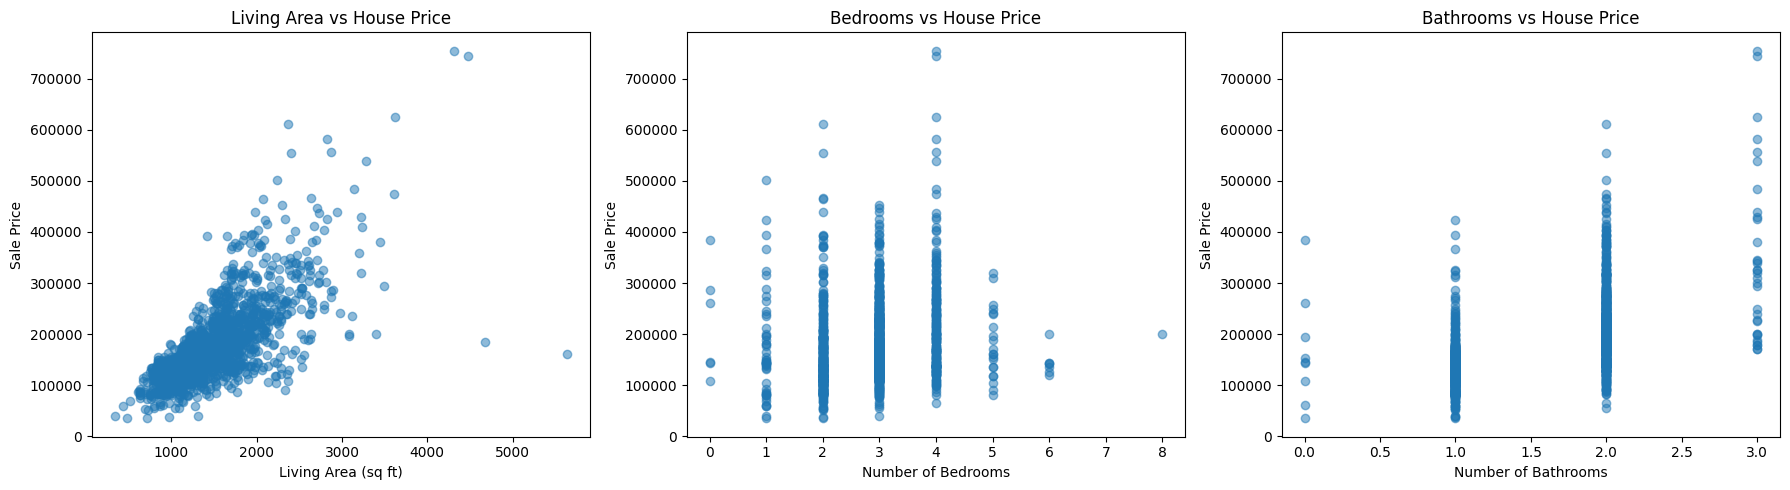

In [16]:
# Visualize the relationship between features and house price

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Square footage vs price
axes[0].scatter(df['GrLivArea'], df['SalePrice'], alpha=0.5)
axes[0].set_xlabel('Living Area (sq ft)')
axes[0].set_ylabel('Sale Price')
axes[0].set_title('Living Area vs House Price')

# Bedrooms vs price
axes[1].scatter(df['BedroomAbvGr'], df['SalePrice'], alpha=0.5)
axes[1].set_xlabel('Number of Bedrooms')
axes[1].set_ylabel('Sale Price')
axes[1].set_title('Bedrooms vs House Price')

# Bathrooms vs price
axes[2].scatter(df['FullBath'], df['SalePrice'], alpha=0.5)
axes[2].set_xlabel('Number of Bathrooms')
axes[2].set_ylabel('Sale Price')
axes[2].set_title('Bathrooms vs House Price')

plt.tight_layout()
plt.show()

## 6. Preparing Features and Target Variable

The input features and target variable were separated for training the machine learning model.

The input features (`X`) consist of living area, number of bedrooms, and number of full bathrooms.

The target variable (`y`) is the house sale price (`SalePrice`) that the model will learn to predict.

In [17]:
# Select features and target

X = df[['GrLivArea', 'BedroomAbvGr', 'FullBath']]
y = df['SalePrice']

print("Features (X):")
print(X.head())

print("\nTarget (y):")
print(y.head())

Features (X):
   GrLivArea  BedroomAbvGr  FullBath
0       1710             3         2
1       1262             3         2
2       1786             3         2
3       1717             3         1
4       2198             4         2

Target (y):
0    208500
1    181500
2    223500
3    140000
4    250000
Name: SalePrice, dtype: int64


## 7. Train-Test Split

The dataset was divided into training and testing sets using an 80:20 ratio.

80% of the data is used to train the Linear Regression model, while the remaining 20% is used to evaluate its performance on unseen data.

A random state of 42 was used to ensure reproducibility of the results.

In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training data:", X_train.shape)
print("Testing data :", X_test.shape)

Training data: (1168, 3)
Testing data : (292, 3)


## 8. Model Training

A Multiple Linear Regression model was created using the selected features.

The model was trained using the training dataset to learn the relationship between living area, number of bedrooms, number of full bathrooms, and house price.

In [19]:
from sklearn.linear_model import LinearRegression

# Create the Linear Regression model
model = LinearRegression()

# Train the model
model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


## 9. Making Predictions

The trained Linear Regression model was used to predict house prices for the test dataset.

The predictions generated by the model are compared with the actual house prices during the model evaluation stage.

In [20]:
# Make predictions on the test data

y_pred = model.predict(X_test)

print("Predictions made successfully!")
print(y_pred[:10])

Predictions made successfully!
[113410.67255298 305081.87775899 135904.78562983 205424.67564124
 227502.68349004 121157.48079629 205577.98056584 183787.20378269
 121157.48079629 147219.22233196]


## 10. Model Evaluation

The performance of the Multiple Linear Regression model was evaluated using four standard regression metrics:

- **MAE (Mean Absolute Error)** — measures the average absolute difference between actual and predicted prices.
- **MSE (Mean Squared Error)** — measures the average squared difference between actual and predicted prices.
- **RMSE (Root Mean Squared Error)** — represents the typical prediction error in the same units as the target variable.
- **R² Score** — indicates how much of the variation in house prices is explained by the model.

In [21]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Model Evaluation:")
print("------------------")
print("MAE  :", mae)
print("MSE  :", mse)
print("RMSE :", rmse)
print("R²   :", r2)

Model Evaluation:
------------------
MAE  : 35788.061292436294
MSE  : 2806426667.247853
RMSE : 52975.71771338122
R²   : 0.6341189942328371


## 11. Actual vs Predicted House Prices

The actual house prices were compared with the prices predicted by the Linear Regression model.

A scatter plot was created to visualize the relationship between actual and predicted prices.

The dashed diagonal line represents perfect predictions, where the predicted price is equal to the actual price.

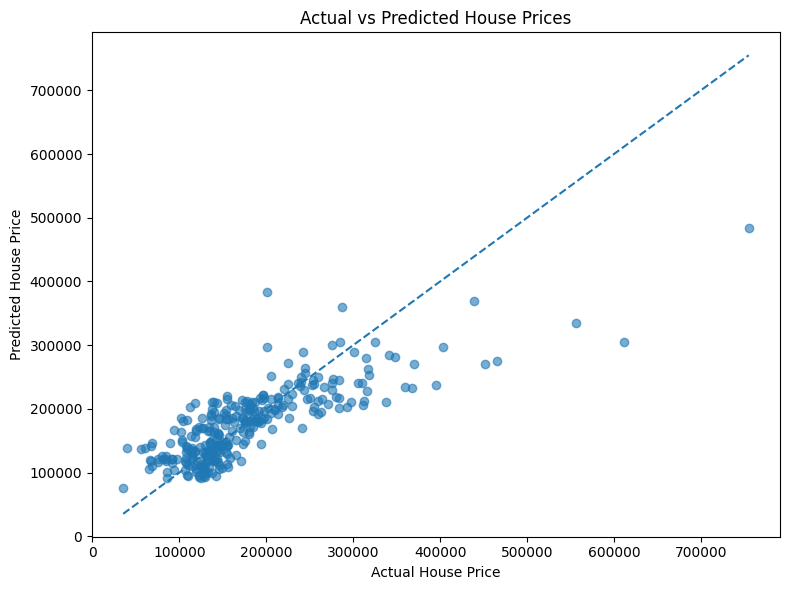

In [22]:
# Plot actual vs predicted house prices

plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred, alpha=0.6)

# Perfect prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle='--'
)

plt.xlabel('Actual House Price')
plt.ylabel('Predicted House Price')
plt.title('Actual vs Predicted House Prices')

plt.tight_layout()
plt.show()

## 12. Comparison of Actual and Predicted Prices

A comparison table was created to examine the actual house prices against the prices predicted by the Linear Regression model.

The table displays the first 10 test-set observations to show how closely the predicted prices match the actual prices.

In [23]:
# Compare actual and predicted prices

comparison = pd.DataFrame({
    'Actual Price': y_test.values,
    'Predicted Price': y_pred
})

comparison.head(10)

,Actual Price,Predicted Price
0,154500,113410.672553
1,325000,305081.877759
2,115000,135904.785630
3,159000,205424.675641
4,315500,227502.683490
5,75500,121157.480796
6,311500,205577.980566
7,146000,183787.203783
8,84500,121157.480796
9,135500,147219.222332


### Evaluation Results

The trained model was evaluated using four regression metrics: Mean Absolute Error (MAE), Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and R² Score.

These metrics provide an overview of the prediction error and the overall performance of the Linear Regression model.

In [24]:
print("MAE  :", mae)
print("MSE  :", mse)
print("RMSE :", rmse)
print("R²   :", r2)

MAE  : 35788.061292436294
MSE  : 2806426667.247853
RMSE : 52975.71771338122
R²   : 0.6341189942328371


## 13. Model Coefficients

The coefficients of the Linear Regression model were calculated to understand the relationship between each selected feature and the predicted house price.

The coefficients represent the change in the predicted house price associated with a one-unit increase in a feature, while keeping the other features constant.

In [25]:
# Display model coefficients

coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

print("Model Intercept:", model.intercept_)
coefficients

Model Intercept: 52261.74862694461


,Feature,Coefficient
0,GrLivArea,104.026307
1,BedroomAbvGr,-26655.165357
2,FullBath,30014.324109


## 14. New House Price Prediction

The trained Linear Regression model was used to predict the price of a new house.

For this example, the house has a living area of 2,000 square feet, 3 bedrooms, and 2 full bathrooms.

The model uses these features to generate the predicted house price.

In [26]:
# Final new-house prediction

from sklearn.linear_model import LinearRegression

# Re-create and train the model
model = LinearRegression()
model.fit(X_train, y_train)

# Create a new house
new_house = pd.DataFrame({
    'GrLivArea': [2000],
    'BedroomAbvGr': [3],
    'FullBath': [2]
})

# Directly make the prediction
prediction = model.predict(new_house)

print("Predicted House Price:", prediction[0])

Predicted House Price: 240377.51479736282
